## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 

If students address the detailed feedback in a future checkpoint they will earn these points back


|                  | Unsatisfactory                                                                                                                                                                                                    | Developing                                                                                                                                                                                              | Proficient                                     | Excellent                                                                                                                              |
|------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------|
| Data relevance   | Did not have data relevant to their question. Or the datasets don't work together because there is no way to line them up against each other. If there are multiple datasets, most of them have this trouble | Data was only tangentially relevant to the question or a bad proxy for the question. If there are multiple datasets, some of them may be irrelevant or can't be easily combined.                       | All data sources are relevant to the question. | Multiple data sources for each aspect of the project. It's clear how the data supports the needs of the project.                         |
| Data description | Dataset or its cleaning procedures are not described. If there are multiple datasets, most have this trouble                                                                                              | Data was not fully described. If there are multiple datasets, some of them are not fully described                                                                                                      | Data was fully described                       | The details of the data descriptions and perhaps some very basic EDA also make it clear how the data supports the needs of the project. |
| Data wrangling   | Did not obtain data. They did not clean/tidy the data they obtained.  If there are multiple datasets, most have this trouble                                                                                 | Data was partially cleaned or tidied. Perhaps you struggled to verify that the data was clean because they did not present it well. If there are multiple datasets, some have this trouble | The data is cleaned and tidied.                | The data is spotless and they used tools to visualize the data cleanliness and you were convinced at first glance                      |


# COGS 108 - Data Checkpoint

## Authors

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member, please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Paco Yan: Conceptualization, Data curation, Methodology, shooting granny(Kaboom) Writing - draft
- Dylan Truong:  Analysis, Software, Visualization 
- Diego Jimenez: Project administration, Software, Writing,  - review & editing
- Pan Zhong: Analysis, Background research, Writing 
- Xavier Lu: Analysis, Background research, Writing

## Research Question The Industry Evidence (Tom's Hardware, November 2025)

Title: "Bewildered enthusiasts decry memory price increases of 100% or more — the AI RAM squeeze is finally starting to hit PC builders where it hurts"



## Background and Prior Work The Historical Comparison (Prior Work) (Kaggle, Maharshi Pandya)

Title: "Cryptocurrency Historical Prices Dataset"

## Hypothesis


We hypothesize that the price per gigabyte of consumer RAM decreases over time following the release of a new generation (DDR4/DDR5), but that this decline slows or temporarily reverses after 2022 due to increased demand for HBM driven by AI applications.

We will test this by comparing the slope of price decline before and after 2022. If the rate of price decrease becomes significantly smaller or positive after 2022, we will reject the standard depreciation model and conclude that AI demand has disrupted historical pricing trends.

Reasoning: New manufacturing processes (like DDR5) initially have low yields and high R&D recovery costs. As production scales and yields improve, prices drop rapidly before stabilizing. We expect high-speed, low-latency kits to retain value longer than standard "budget" kits.


## Data

### Data overview

We are utilizing a comprehensive historical RAM pricing dataset compiled from major U.S. electronics retailers (such as Amazon and Newegg) via historical price trackers. This dataset captures the monthly average prices of consumer memory kits to track market fluctuations.

The raw dataset contains 1,392 unique RAM kits tracked across 98 distinct months. To prepare this data for time-series analysis, we "melted" the dataset from a wide format into a tidy, long format and engineered the following key variables:

Date: Monthly observations from January 2018 through February 2026.

Price (USD): The historical market price of the kit at that specific month.

Total Capacity (GB): Extracted from the module configuration (e.g., calculating 32GB from a "2 x 16GB" kit).

RAM Type: Categorical variable denoting the generation (DDR4 vs. DDR5).

Speed (MHz) & CAS Latency: Performance metrics used to identify high-end vs. budget kits.

Price Per Gigabyte (USD/GB): Our primary standardized metric, computed by dividing the kit's price by its total capacity, allowing for direct economic comparisons across entirely different product tiers.

Our analysis focuses heavily on the timeline from 2018 to early 2026. This specific window is crucial as it captures a highly stable "Pre-AI" baseline (2018–2021), the launch of DDR5 memory (late 2021), and the "Post-AI Expansion" period following the release of ChatGPT in November 2022.

Data Processing & Storage:
All data storage, cleaning, and exploratory data analysis (EDA) is executed within JupyterLab using Python's pandas and seaborn libraries. During our cleaning phase, we specifically accounted for real-world market anomalies, such as forward-filling missing prices for out-of-stock items, and removing "ghost data" caused by third-party sellers recycling old product listings prior to the official launch of DDR5.

In [12]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set plot style for cleaner graphs
sns.set(style="whitegrid")

#Load the massive historical dataset
#IMPORTANT: Make sure this file is in your 'data/00-raw/' folder
file_path = 'https://raw.githubusercontent.com/COGS108/Group115_WI26/refs/heads/master/data/00-raw/RamData_Full_History_2018_2026.csv' 

try:
    df = pd.read_csv(file_path)
    print("Historical Dataset Loaded Successfully!")
    print(f"Initial shape (Wide Format): {df.shape}")
    display(df.head(5))
except FileNotFoundError:
    print(f"ERROR: The file was not found at {file_path}")

Historical Dataset Loaded Successfully!
Initial shape (Wide Format): (1392, 108)


,Name,Speed,Module,First Word Latency,CAS Latency,Price Per GB,Color,Rating,Review Count,Price_2018_01,...,Price_2025_06,Price_2025_07,Price_2025_08,Price_2025_09,Price_2025_10,Price_2025_11,Price_2025_12,Price_2026_01,Price_2026_02,Price_Current_2026_2_18
0,Crucial Pro Overclocking 32 GB,DDR5-6000,2 x 16GB,12 ns,36,$8.56,Black,4.5,45,NaN,...,$232.89,$239.74,$246.59,$253.44,$115.08,$186.31,$273.99,$347.97,$326.05,$325.99
1,Corsair Vengeance RGB 32 GB,DDR5-6000,2 x 16GB,12 ns,36,$12.75,Black,4.5,89,NaN,...,$346.79,$356.99,$367.19,$377.39,$171.36,$277.43,$407.99,$518.15,$485.51,$439.99
2,Corsair Vengeance LPX 32 GB,DDR4-3200,2 x 16GB,10 ns,16,$5.34,Black / Yellow,4.5,72,$240.81,...,$145.34,$149.62,$153.89,$158.17,$71.82,$116.27,$170.99,$249.65,$273.58,$269.00
3,G.Skill Flare X5 32 GB,DDR5-6000,2 x 16GB,12 ns,36,$11.41,Black,4.5,110,NaN,...,$310.25,$319.38,$328.50,$337.62,$153.30,$248.20,$365.00,$463.55,$434.35,$449.99
4,Corsair Vengeance LPX 16 GB,DDR4-3200,2 x 8GB,10 ns,16,$7.06,Black / Yellow,4.5,511,$159.13,...,$96.04,$98.87,$101.69,$104.52,$47.46,$76.83,$112.99,$164.97,$180.78,$144.99


### Dataset #1 

Instructions: 
1. Change the header from Dataset #1 to something more descriptive of the dataset
2. Write a few paragraphs about this dataset. Make sure to cover
   1. Describe the important metrics, what units they are in, and giv some sense of what they mean.  For example "Fasting blood glucose in units of mg glucose per deciliter of blood.  Normal values for healthy individuals range from 70 to 100 mg/dL.  Values 100-125 are prediabetic and values >125mg/dL indicate diabetes. Values <70 indicate hypoglycemia. Fasting idicates the patient hasn't eaten in the last 8 hours.  If blood glucose is >250 or <50 at any time (regardless of the time of last meal) the patient's life may be in immediate danger"
   2. If there are any major concerns with the dataset, describe them. For example "Dataset is composed of people who are serious enough about eating healthy that they voluntarily downloaded an app dedicated to tracking their eating patterns. This sample is likely biased because of that self-selection. These people own smartphones and may be healthier and may have more disposable income than the average person.  Those who voluntarily log conscientiously and for long amounts of time are also likely even more interested in health than those who download the app and only log a bit before getting tired of it"
3. Use the cell below to 
    1. load the dataset 
    2. make the dataset tidy or demonstrate that it was already tidy
    3. demonstrate the size of the dataset
    4. find out how much data is missing, where its missing, and if its missing at random or seems to have any systematic relationships in its missingness
    5. find and flag any outliers or suspicious entries
    6. clean the data or demonstrate that it was already clean.  You may choose how to deal with missingness (dropna of fillna... how='any' or 'all') and you should justify your choice in some way
    7. You will load raw data from `data/00-raw/`, you will (optionally) write intermediate stages of your work to `data/01-interim` and you will write the final fully wrangled version of your data to `data/02-processed`
4. Optionally you can also show some summary statistics for variables that you think are important to the project
5. Feel free to add more cells here if that's helpful for you


In [14]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE

# 2. Tidying the Data ("Melting" from Wide to Long format)

# A. Identify the columns that contain the monthly prices
# We are grabbing every column that starts with 'Price_'
price_columns = [col for col in df.columns if col.startswith('Price_')]

# B. Melt the dataframe down!
df_melted = pd.melt(df, 
                    id_vars=['Name', 'Speed', 'Module', 'First Word Latency', 'CAS Latency', 'Color', 'Rating', 'Review Count'], 
                    value_vars=price_columns,
                    var_name='Date_String', 
                    value_name='Raw_Price')

# C. Clean the Date Column
# We convert strings like 'Price_2018_01' or 'Price_Current_2026_2_18' into clean datetime objects
df_melted['Clean_Date_Str'] = df_melted['Date_String'].str.replace('Price_', '').str.replace('Current_', '').str.replace('_', '-')
df_melted['Date'] = pd.to_datetime(df_melted['Clean_Date_Str'], format='mixed', errors='coerce')

# Drop the messy string columns
df_melted = df_melted.drop(columns=['Date_String', 'Clean_Date_Str'])

# D. Extract DDR Generation from 'Speed' (e.g., 'DDR5-6000' -> 'DDR5')
df_melted['DDR_Type'] = df_melted['Speed'].astype(str).str.split('-').str[0]

# E. Calculate 'Total_GB' from 'Module' (e.g., "2 x 16GB" -> 32)
def calculate_total_gb(module_str):
    try:
        mod_str = str(module_str).upper().replace('GB', '').strip()
        if 'X' in mod_str:
            parts = mod_str.split('X')
            return int(parts[0]) * int(parts[1])
        else:
            return int(mod_str)
    except:
        return np.nan

df_melted['Total_GB'] = df_melted['Module'].apply(calculate_total_gb)

# F. Clean Price column and Calculate the golden metric: Price_Per_GB
df_melted['Clean_Price'] = df_melted['Raw_Price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_melted['Clean_Price'] = pd.to_numeric(df_melted['Clean_Price'], errors='coerce')

df_melted['Price_Per_GB'] = df_melted['Clean_Price'] / df_melted['Total_GB']

# Sort by Kit Name and Date for proper time-series flow
df_clean = df_melted.sort_values(by=['Name', 'Date']).reset_index(drop=True)

print("\nData after Tidying and Feature Engineering (Long Format):")
print(f"New shape: {df_clean.shape}")
display(df_clean[['Name', 'Date', 'DDR_Type', 'Total_GB', 'Clean_Price', 'Price_Per_GB']].head())



Data after Tidying and Feature Engineering (Long Format):
New shape: (137808, 14)


,Name,Date,DDR_Type,Total_GB,Clean_Price,Price_Per_GB
0,ADATA XPG GAMMIX D20 32 GB,2018-01-01,DDR4,32,352.07,11.002187
1,ADATA XPG GAMMIX D20 32 GB,2018-02-01,DDR4,32,354.15,11.067187
2,ADATA XPG GAMMIX D20 32 GB,2018-03-01,DDR4,32,356.24,11.132500
3,ADATA XPG GAMMIX D20 32 GB,2018-04-01,DDR4,32,358.32,11.197500
4,ADATA XPG GAMMIX D20 32 GB,2018-05-01,DDR4,32,360.40,11.262500


Missing prices BEFORE handling: 38870
Ghost data removed successfully!
Missing prices AFTER handling: 0


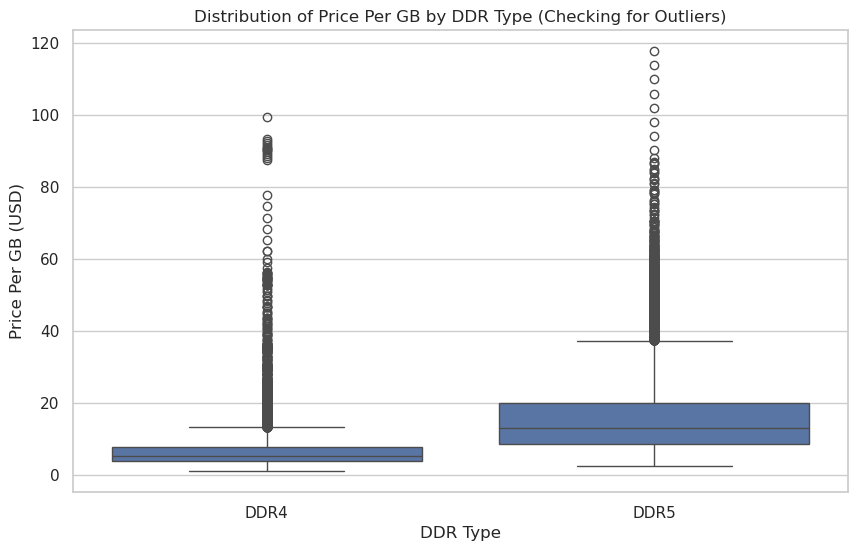

In [15]:

# 3. Handling Missingness, Outliers, and Ghost Data

print("Missing prices BEFORE handling:", df_clean['Price_Per_GB'].isnull().sum())

# Strategy Step 1: Forward Fill (ffill) gaps inside an existing product's lifespan
# If a kit was in stock Month 1, missing Month 2, and back in Month 3, we assume the price held steady.
df_clean['Price_Per_GB'] = df_clean.groupby('Name')['Price_Per_GB'].ffill()

# Strategy Step 2: Drop legitimate NaNs from before a product existed
# DDR5 kits have NaNs from 2018-2020 because they literally weren't invented yet. 
df_clean = df_clean.dropna(subset=['Price_Per_GB', 'Date'])

# --- THE GHOST LINE FIX ---
# DDR5 launched on Nov 4, 2021. Any DDR5 data before this is a recycled listing error.
ddr5_launch_date = pd.to_datetime('2021-11-04')

# Keep the row IF it is DDR4, OR if it is DDR5 *and* the date is on/after launch
df_clean = df_clean[(df_clean['DDR_Type'] == 'DDR4') | 
                    ((df_clean['DDR_Type'] == 'DDR5') & (df_clean['Date'] >= ddr5_launch_date))]

print("Ghost data removed successfully!")
print("Missing prices AFTER handling:", df_clean['Price_Per_GB'].isnull().sum())

# Outlier Detection Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='DDR_Type', y='Price_Per_GB', data=df_clean)
plt.title('Distribution of Price Per GB by DDR Type (Checking for Outliers)')
plt.ylabel('Price Per GB (USD)')
plt.xlabel('DDR Type')
plt.show()

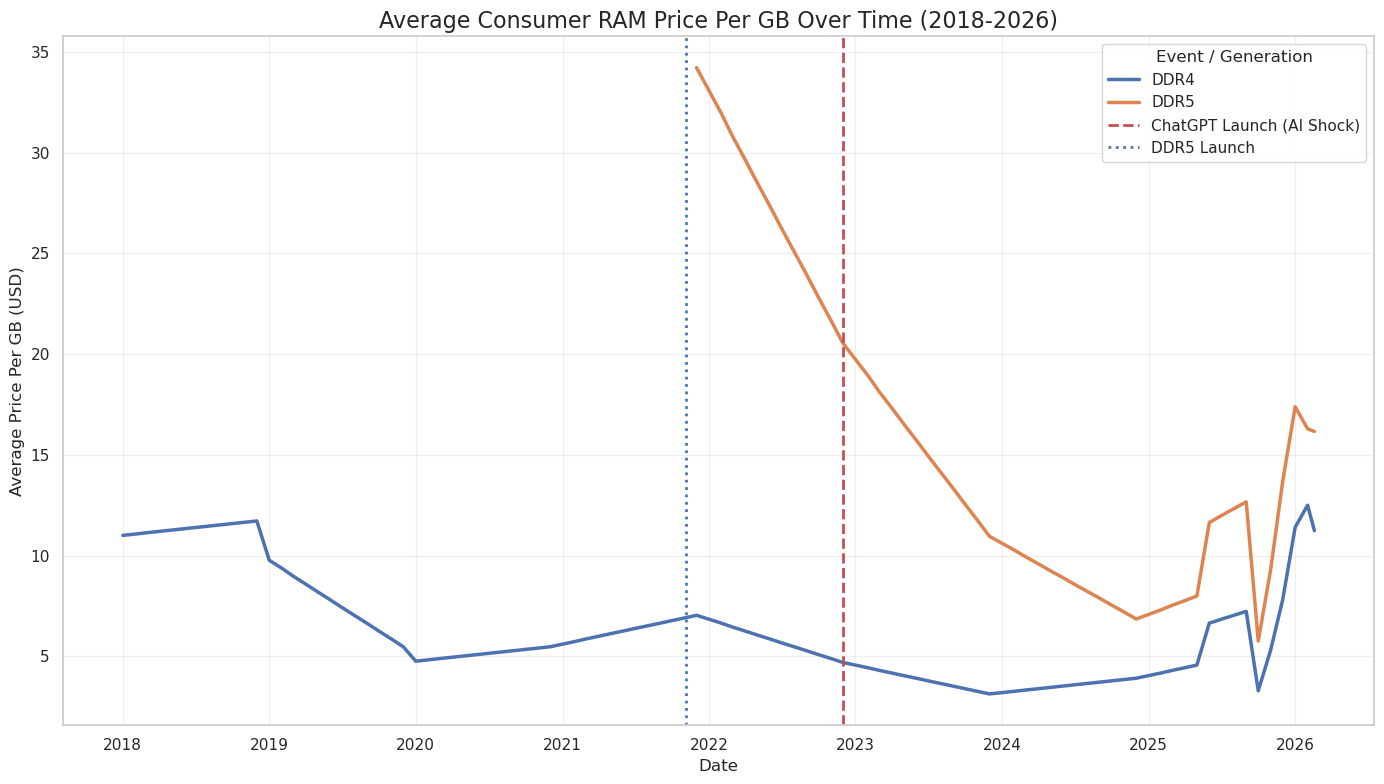


BOOM! Final tidy dataset with 98093 rows saved to: data/02-processed/Historical_RAM_Pricing_Cleaned.csv


In [16]:

# 4. Exploratory Data Analysis (EDA)
import os # Make sure os is imported to handle folder creation

# Time-Series Line Plot (The defining graph for your project hypothesis)
plt.figure(figsize=(14, 8))

# We group by Date and DDR type to get the market average per month
monthly_avg = df_clean.groupby(['Date', 'DDR_Type'])['Price_Per_GB'].mean().reset_index()

sns.lineplot(x='Date', y='Price_Per_GB', hue='DDR_Type', data=monthly_avg, linewidth=2.5)

# Add a vertical red line for the "AI Shock" date
plt.axvline(pd.to_datetime('2022-11-30'), color='r', linestyle='--', linewidth=2, label='ChatGPT Launch (AI Shock)')

# Add a vertical blue line for the DDR5 launch
plt.axvline(pd.to_datetime('2021-11-04'), color='b', linestyle=':', linewidth=2, label='DDR5 Launch')

plt.title('Average Consumer RAM Price Per GB Over Time (2018-2026)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Price Per GB (USD)', fontsize=12)
plt.legend(title='Event / Generation', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# C. Save the Final Processed Data
output_path = 'data/02-processed/Historical_RAM_Pricing_Cleaned.csv'

# THE FIX: Extract the folder path and create it if it doesn't exist!
output_folder = os.path.dirname(output_path)
os.makedirs(output_folder, exist_ok=True) 

# Now save the file
df_clean.to_csv(output_path, index=False)
print(f"\nBOOM! Final tidy dataset with {df_clean.shape[0]} rows saved to: {output_path}")

### Dataset #2 

See instructions above for Dataset #1.  Feel free to keep adding as many more datasets as you need.  Put each new dataset in its own section just like these. 

Lastly if you do have multiple datasets, add another section where you demonstrate how you will join, align, cross-reference or whatever to combine data from the different datasets

Please note that you can always keep adding more datasets in the future if these datasets you turn in for the checkpoint aren't sufficient.  The goal here is demonstrate that you can obtain and wrangle data.  You are not tied down to only use what you turn in right now.

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE


## Ethics

Data Biases: Our pricing data will likely be sourced from major US retailers (like Amazon or Newegg). This creates a geographic bias, as it may not reflect the hardware accessibility issues faced by consumers in other parts of the world.
Economic Implications: If our hypothesis is correct, it highlights a form of "technological gentrification," where enterprise demand for AI makes basic computing hardware more expensive for students and low-income individuals. Discussing this aligns with the course goal of understanding the social impact of data.
Privacy: The data involves public product prices and stock market figures. No personally identifiable information (PII) of individuals will be collected or analyzed.


## Team Expectations 

Communication: We will communicate primarily via a dedicated Discord channel. All members are expected to check the channel daily and respond to messages within 24 hours.
Meetings: We will hold a weekly meeting in-person to review progress and assign tasks.
Conflict Resolution: If a disagreement arises regarding analysis methods or workload, we will first attempt to resolve it through a majority vote. If a resolution cannot be reached, we will consult the TA for guidance. (Democracy)
Accountability: Each member is responsible for their assigned section. If a member anticipates missing a deadline, they must notify the team at least 48 hours in advance so tasks can be redistributed. (Getting carpet bomb)
Policy Agreement: By submitting this proposal, we confirm that we have read the COGS 108 Team Policies and agree to adhere to the expectations outlined above.

## Project Timeline Proposal

Week 1-2: 

Finalize proposal and secure the PCPartPicker pricing dataset.

Week 3 : 

Collect data

Week 4 : 

meet with group(chat about data/ how to formulate)

Week 5-7: 

(Checkpoint #1): Clean the data (standardize "Price per GB" across different kit sizes).

(Checkpoint #2) EDA. Visualizing the price trends of RAM alongside NVDA stock price over time.


Week 8: 

Statistical Analysis. Perform correlation analysis and potentially a linear regression to see if "AI Date" is a significant predictor of "RAM Price."

Draft Final Report and record Video.

Week 10: 

Final submission.